# Descriptive Statistical Analysis — Annual Maximum Daily Rainfall and IDF Curves by Municipality (Brazil)

This notebook consolidates the results generated by `extrair_chuva_maxima.py` (annual maximum daily rainfall series, 1961–2025, Xavier BR-DWGD grid) and `calcular_idf_municipios.py` (IDF curves calibrated per municipality), with national and per-state descriptive statistics, heatmaps, and choropleth maps (`geobr`). The goal is to serve as a base report for writing a paper.

**Data sources:**
- `xavier_chuva_maxima_diaria_anual_municipios_1961_2025.json` — 362,115 records (5,571 municipalities × 65 years)
- `idf_municipios.json` — IDF curves for 5,569 municipalities
- `idf_municipios_ignorados.json` — municipalities without a valid series

**Before citing any number from this notebook in the paper, see the "Methodological limitations" section at the end** — especially the fact that the `b` and `c` coefficients of the IDF equation come out practically constant nationwide (an effect of the fixed DAEE/CETESB disaggregation factors, not a real finding about the regional rainfall regime).


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geobr

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

BASE = Path.cwd()


## 1. Data loading and preparation

The IBGE code already contains the state code in its first 2 digits (e.g. `51` = Mato Grosso) — used here to fix a record with an empty state in the centroids asset (see note just below).

In [2]:
CODIGO_UF = {
    '11': 'RO', '12': 'AC', '13': 'AM', '14': 'RR', '15': 'PA', '16': 'AP', '17': 'TO',
    '21': 'MA', '22': 'PI', '23': 'CE', '24': 'RN', '25': 'PB', '26': 'PE', '27': 'AL', '28': 'SE', '29': 'BA',
    '31': 'MG', '32': 'ES', '33': 'RJ', '35': 'SP',
    '41': 'PR', '42': 'SC', '43': 'RS',
    '50': 'MS', '51': 'MT', '52': 'GO', '53': 'DF',
}


def corrigir_uf(codigo_ibge, uf):
    return uf if uf else CODIGO_UF.get(codigo_ibge[:2], uf)


with open(BASE / 'xavier_chuva_maxima_diaria_anual_municipios_1961_2025.json', encoding='utf-8') as f:
    df_long = pd.DataFrame(json.load(f))
df_long['uf'] = df_long.apply(lambda r: corrigir_uf(r['codigo_ibge'], r['uf']), axis=1)

DURACOES = ['5 min', '10 min', '15 min', '20 min', '25 min', '30 min', '60 min',
            '360 min', '480 min', '600 min', '720 min', '1440 min']
PERIODOS_RETORNO = [5, 10, 25, 50, 100]

with open(BASE / 'idf_municipios.json', encoding='utf-8') as f:
    idf_registros = json.load(f)

linhas_idf = []
for r in idf_registros:
    linha = {
        'codigo_ibge': r['codigo_ibge'], 'nome_municipio': r['nome_municipio'], 'uf': r['uf'],
        'n_anos': r['n_anos'], 'distribuicao': r['distribuicao'],
        'ks_d': r['ks_d'], 'ks_p_valor': r['ks_p_valor'],
        'idf_k': r['idf']['k'], 'idf_a': r['idf']['a'], 'idf_b': r['idf']['b'], 'idf_c': r['idf']['c'],
        'idf_r2': r['idf']['r2'], 'idf_mae': r['idf']['mae'], 'idf_rmse': r['idf']['rmse'],
    }
    for duracao in DURACOES:
        chave = duracao.replace(' ', '')
        for tr in PERIODOS_RETORNO:
            linha[f'i_{chave}_{tr}anos'] = r['quantis_mm_h'][duracao][str(tr)]
    linhas_idf.append(linha)

df_idf = pd.DataFrame(linhas_idf)
df_idf['uf'] = df_idf.apply(lambda r: corrigir_uf(r['codigo_ibge'], r['uf']), axis=1)

with open(BASE / 'idf_municipios_ignorados.json', encoding='utf-8') as f:
    df_ignorados = pd.DataFrame(json.load(f))

print(f'Série bruta: {len(df_long):,} registros ({df_long["codigo_ibge"].nunique()} municípios x {df_long["ano"].nunique()} anos)')
print(f'Municípios com curva IDF: {len(df_idf)}')
print(f'Municípios ignorados (dados insuficientes): {len(df_ignorados)}')
df_ignorados


Série bruta: 362,115 registros (5571 municípios x 65 anos)
Municípios com curva IDF: 5569
Municípios ignorados (dados insuficientes): 2


,codigo_ibge,nome_municipio,motivo
0,3205309,Vitória,"dados insuficientes (0 ano(s) válido(s), mínim..."
1,2605459,Fernando de Noronha,"dados insuficientes (0 ano(s) válido(s), mínim..."


### Known data anomalies (see `MEMORIA_PROJETO.md` for the full history)

- **Fernando de Noronha (PE)** and **Vitória (ES)**: no valid series (island outside the Xavier grid coverage; asset centroid falling in the ocean, respectively) — excluded from every statistic in this notebook.
- **Boa Esperança do Norte (MT, code 5101837)**: had an empty state in the centroids asset (fixed above) and **has no polygon in the 2020 `geobr` mesh** used for the municipal maps — so it doesn't appear at all on the municipal map (neither gray nor colored: it simply doesn't exist in that mesh), even though it's present in every table and statistic. Confirmed as a valid, active municipality in the IBGE API (likely more recent than the 2020 geographic base used).

In [3]:
df_resumo_mun = (
    df_long.dropna(subset=['chuva_max_diaria_mm'])
    .groupby(['codigo_ibge', 'nome_municipio', 'uf'])['chuva_max_diaria_mm']
    .agg(chuva_media='mean', chuva_desvio='std', chuva_mediana='median', chuva_min='min', chuva_max='max', n_anos_validos='count')
    .reset_index()
)
df_resumo_mun['cv'] = df_resumo_mun['chuva_desvio'] / df_resumo_mun['chuva_media']

df = df_resumo_mun.merge(df_idf.drop(columns=['n_anos']), on=['codigo_ibge', 'nome_municipio', 'uf'], how='inner')
print('Tabela consolidada (1 linha por município):', df.shape)
df.head()


Tabela consolidada (1 linha por município): (5569, 80)


,codigo_ibge,nome_municipio,uf,chuva_media,chuva_desvio,chuva_mediana,chuva_min,chuva_max,n_anos_validos,cv,distribuicao,ks_d,ks_p_valor,idf_k,idf_a,idf_b,idf_c,idf_r2,idf_mae,idf_rmse,i_5min_5anos,i_5min_10anos,i_5min_25anos,i_5min_50anos,i_5min_100anos,...,i_360min_5anos,i_360min_10anos,i_360min_25anos,i_360min_50anos,i_360min_100anos,i_480min_5anos,i_480min_10anos,i_480min_25anos,i_480min_50anos,i_480min_100anos,i_600min_5anos,i_600min_10anos,i_600min_25anos,i_600min_50anos,i_600min_100anos,i_720min_5anos,i_720min_10anos,i_720min_25anos,i_720min_50anos,i_720min_100anos,i_1440min_5anos,i_1440min_10anos,i_1440min_25anos,i_1440min_50anos,i_1440min_100anos
0,1100015,Alta Floresta D'Oeste,RO,55.462059,15.382759,52.804767,30.913855,116.328239,65,0.277356,Gumbel,0.067515,0.908862,638.637333,0.141590,11.827174,0.757954,0.999188,0.672048,1.133864,95.026973,107.227566,122.643047,134.079132,145.430774,...,8.992635,10.147207,11.606012,12.688236,13.762470,7.306516,8.244606,9.429885,10.309192,11.182007,6.144967,6.933925,7.930775,8.670295,9.404355,5.308153,5.989671,6.850771,7.489584,8.123680,3.122443,3.523336,4.029865,4.405638,4.778635
1,1100023,Ariquemes,RO,66.410579,14.427889,63.358824,38.934114,117.049238,65,0.217253,Gumbel,0.077029,0.806950,766.652765,0.128184,11.827174,0.757954,0.999271,0.736919,1.227652,111.898821,124.623023,140.700086,152.626969,164.465787,...,10.589259,11.793382,13.314793,14.443464,15.563800,8.603773,9.582123,10.818270,11.735314,12.645587,7.235994,8.058811,9.098442,9.869700,10.635263,6.250604,6.961371,7.859427,8.525656,9.186965,3.676826,4.094924,4.623192,5.015092,5.404097
2,1100031,Cabixi,RO,50.940416,13.653566,48.204105,28.998057,108.651313,65,0.268030,GEV,0.067782,0.906481,581.366636,0.145176,11.827174,0.757954,0.999232,0.605020,1.016698,87.097981,98.356394,112.825280,123.737859,134.722802,...,8.242295,9.307706,10.676932,11.709616,12.749148,6.696865,7.562511,8.675008,9.514063,10.358683,5.632235,6.360266,7.295904,8.001571,8.711918,4.865244,5.494132,6.302356,6.911926,7.525539,2.861908,3.231842,3.707268,4.065839,4.426788
3,1100049,Cacoal,RO,54.795148,12.606384,52.907767,31.648588,92.185062,65,0.230064,GEV,0.046868,0.997574,662.190369,0.109069,11.827174,0.757954,0.999128,0.642022,1.083169,93.411217,103.225745,114.642499,122.455685,129.698957,...,8.839732,9.768505,10.848900,11.588281,12.273730,7.182282,7.936910,8.814731,9.415478,9.972405,6.040484,6.675145,7.413415,7.918659,8.387049,5.217897,5.766131,6.403865,6.840305,7.244910,3.069351,3.391842,3.766979,4.023709,4.261712
4,1100056,Cerejeiras,RO,51.257339,13.029428,48.197238,29.746523,88.737999,65,0.254196,Gumbel,0.045488,0.998430,591.595025,0.140992,11.827174,0.757954,0.999192,0.619762,1.045325,87.952064,99.185575,113.379147,123.908750,134.360603,...,8.323119,9.386174,10.729346,11.725788,12.714873,6.762534,7.626266,8.717594,9.527203,10.330834,5.687465,6.413885,7.331720,8.012622,8.688496,4.912952,5.540450,6.333295,6.921472,7.505307,2.889972,3.259088,3.725467,4.071454,4.414886


## 2. National descriptive statistics

Two views: (a) all individual records (municipality × year, 362 thousand points) and (b) each municipality's average over the 65 years (5,569 points) — the second is what characterizes "the municipality," the first shows the year-to-year variability.

=== Chuva máxima diária anual (mm/dia) — todos os registros (município x ano) ===


count    361985.00
mean         59.21
std          21.72
min           5.98
25%          44.46
50%          55.45
75%          69.86
max         301.01
Name: chuva_max_diaria_mm, dtype: float64


=== Chuva máxima diária anual média por município (65 anos cada) ===


count    5569.00
mean       59.21
std        11.60
min        30.37
25%        51.46
50%        57.47
75%        65.44
max       119.64
Name: chuva_media, dtype: float64

/opt/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


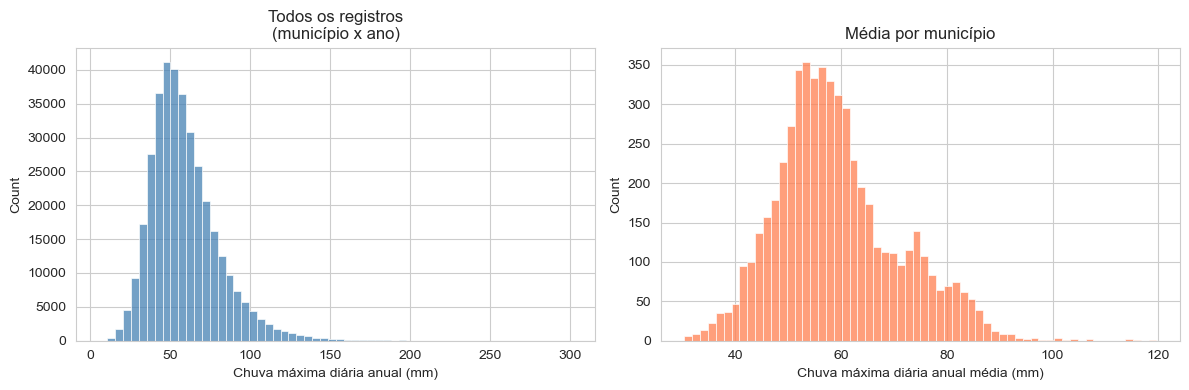

In [4]:
print('=== Chuva máxima diária anual (mm/dia) — todos os registros (município x ano) ===')
display(df_long['chuva_max_diaria_mm'].describe().round(2))

print()
print('=== Chuva máxima diária anual média por município (65 anos cada) ===')
display(df['chuva_media'].describe().round(2))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_long['chuva_max_diaria_mm'].dropna(), bins=60, ax=axs[0], color='steelblue')
axs[0].set_title('Todos os registros\n(município x ano)')
axs[0].set_xlabel('Chuva máxima diária anual (mm)')

sns.histplot(df['chuva_media'], bins=60, ax=axs[1], color='coral')
axs[1].set_title('Média por município')
axs[1].set_xlabel('Chuva máxima diária anual média (mm)')
plt.tight_layout()
plt.show()


## 3. Descriptive statistics by state

Municipalities ordered from the state with the highest to the lowest average annual maximum daily rainfall.

In [5]:
tabela_uf = df.groupby('uf').agg(
    n_municipios=('codigo_ibge', 'count'),
    chuva_media=('chuva_media', 'mean'),
    chuva_desvio=('chuva_media', 'std'),
    cv_medio=('cv', 'mean'),
    idf_r2_medio=('idf_r2', 'mean'),
).round(3).sort_values('chuva_media', ascending=False)
ordem_uf = tabela_uf.index.tolist()
tabela_uf


,n_municipios,chuva_media,chuva_desvio,cv_medio,idf_r2_medio
uf,,,,,
RS,497,77.170,6.169,0.291,0.999
PR,399,73.386,8.864,0.299,0.999
SC,295,73.035,5.907,0.295,0.999
RJ,92,62.932,9.818,0.341,0.999
SP,645,62.136,8.215,0.295,0.999
ES,77,62.132,5.488,0.310,0.999
AC,22,61.987,7.378,0.438,0.999
PA,144,58.568,7.002,0.257,0.999
RO,52,58.025,5.696,0.273,0.999


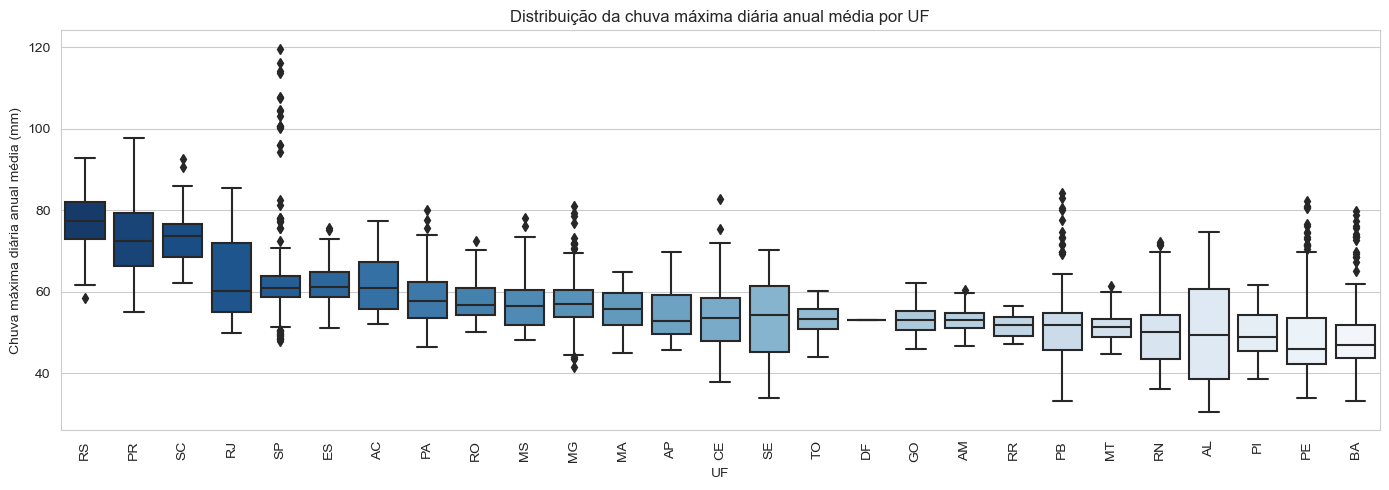

In [6]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x='uf', y='chuva_media', order=ordem_uf, palette='Blues_r')
plt.xticks(rotation=90)
plt.ylabel('Chuva máxima diária anual média (mm)')
plt.xlabel('UF')
plt.title('Distribuição da chuva máxima diária anual média por UF')
plt.tight_layout()
plt.show()


## 4. Winning statistical distribution (Gumbel/GEV/Normal/Log-Normal/Weibull/Gamma)

Which distribution was chosen (lowest KS statistic among those accepted) for each municipality's annual maxima series, and how this varies by state.

Frequência nacional das distribuições escolhidas:


distribuicao
GEV           1489
Weibull       1201
Gumbel        1139
Log-Normal     845
Gama           721
Normal         174
Name: count, dtype: int64

distribuicao
GEV           26.7%
Weibull       21.6%
Gumbel        20.5%
Log-Normal    15.2%
Gama          12.9%
Normal         3.1%
Name: proportion, dtype: object

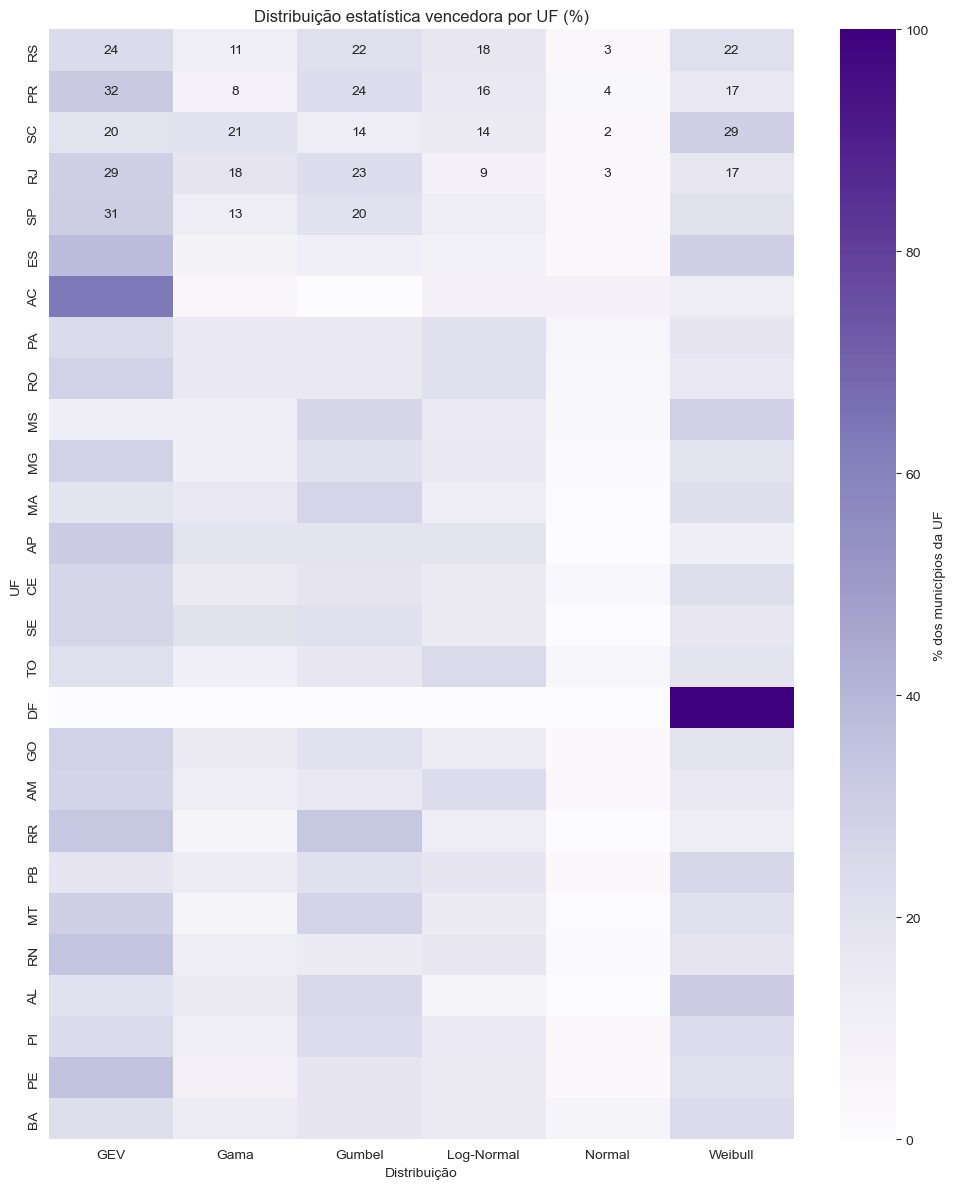

In [7]:
print('Frequência nacional das distribuições escolhidas:')
display(df['distribuicao'].value_counts())
print()
display((100 * df['distribuicao'].value_counts(normalize=True)).round(1).astype(str) + '%')

tabela_dist_pct = pd.crosstab(df['uf'], df['distribuicao'], normalize='index') * 100

plt.figure(figsize=(10, 12))
sns.heatmap(tabela_dist_pct.loc[ordem_uf], annot=True, fmt='.0f', cmap='Purples', cbar_kws={'label': '% dos municípios da UF'})
plt.title('Distribuição estatística vencedora por UF (%)')
plt.xlabel('Distribuição')
plt.ylabel('UF')
plt.tight_layout()
plt.show()


## 5. IDF equation coefficients by state

Equation: `I(T, t) = k · Tᵃ / (t + b)ᶜ` — see `calcular_idf_municipios.py` for the calibration method (log-linear regression with a sweep over `b`).

⚠️ **Note**: as documented in `MEMORIA_PROJETO.md`, `b` and `c` are practically constant across all of Brazil (an effect of the fixed DAEE/CETESB disaggregation factors applied nationwide) — the table below confirms this numerically (standard deviation of `b` and `c` is negligible relative to the mean). Only `k` and `a` carry a real difference between municipalities/states.

In [8]:
tabela_idf_uf = df.groupby('uf')[['idf_k', 'idf_a', 'idf_b', 'idf_c', 'idf_r2']].agg(['mean', 'std']).round(4)
display(tabela_idf_uf)

print(f"Nacional — b: média {df['idf_b'].mean():.3f}, desvio-padrão {df['idf_b'].std():.5f}")
print(f"Nacional — c: média {df['idf_c'].mean():.4f}, desvio-padrão {df['idf_c'].std():.6f}")
print(f"Nacional — k: média {df['idf_k'].mean():.1f}, desvio-padrão {df['idf_k'].std():.1f}")
print(f"Nacional — a: média {df['idf_a'].mean():.4f}, desvio-padrão {df['idf_a'].std():.4f}")


idf_k             idf_a            idf_b       idf_c       idf_r2  \
        mean       std    mean     std     mean  std   mean  std    mean   
uf                                                                         
AC  545.9467  106.1544  0.3174  0.1538  11.8272  0.0  0.758  0.0  0.9992   
AL  593.0668  152.6642  0.1678  0.0295  11.8272  0.0  0.758  0.0  0.9987   
AM  618.4374   48.7725  0.1316  0.0415  11.8272  0.0  0.758  0.0  0.9992   
AP  634.9604   85.6521  0.1360  0.0330  11.8272  0.0  0.758  0.0  0.9992   
BA  579.2043   97.5795  0.1579  0.0336  11.8272  0.0  0.758  0.0  0.9988   
CE  634.8570   96.3315  0.1614  0.0330  11.8272  0.0  0.758  0.0  0.9989   
DF  634.2837       NaN  0.1345     NaN  11.8272  NaN  0.758  NaN  0.9989   
ES  733.5604   67.1892  0.1505  0.0263  11.8272  0.0  0.758  0.0  0.9990   
GO  616.4669   50.5184  0.1454  0.0289  11.8272  0.0  0.758  0.0  0.9991   
MA  652.6744   58.4161  0.1360  0.0242  11.8272  0.0  0.758  0.0  0.9991   
MG  670.3823   65.6364  0.1446  0.0281  11.8272  0.0  0.758  0.0  0.9991   
MS  679.2786   87.1432  0.1318  0.0293  11.8272  0.0  0.758  0.0  0.9991   
MT  590.2709   47.9378  0.1389  0.0319  11.8272  0.0  0.758  0.0  0.9992   
PA  689.9153   94.6703  0.1308  0.0264  11.8272  0.0  0.758  0.0  0.9991   
PB  606.0148  104.8569  0.1686  0.0341  11.8272  0.0  0.758  0.0  0.9988   
PE  573.4381  134.1100  0.1836  0.0466  11.8272  0.0  0.758  0.0  0.9988   
PI  586.1079   74.7121  0.1487  0.0337  11.8272  0.0  0.758  0.0  0.9990   
PR  856.0608  114.3192  0.1499  0.0307  11.8272  0.0  0.758  0.0  0.9991   
RJ  717.4096  122.4536  0.1722  0.0502  11.8272  0.0  0.758  0.0  0.9990   
RN  581.2766  100.3992  0.1808  0.0476  11.8272  0.0  0.758  0.0  0.9989   
RO  656.4958   58.4477  0.1510  0.0719  11.8272  0.0  0.758  0.0  0.9992   
RR  594.8190   40.6693  0.1344  0.0270  11.8272  0.0  0.758  0.0  0.9992   
RS  911.3134   88.0293  0.1418  0.0275  11.8272  0.0  0.758  0.0  0.9991   
SC  857.7662   84.5485  0.1488  0.0311  11.8272  0.0  0.758  0.0  0.9990   
SE  625.4280  109.3508  0.1748  0.0203  11.8272  0.0  0.758  0.0  0.9988   
SP  720.9191  107.0343  0.1519  0.0334  11.8272  0.0  0.758  0.0  0.9991   
TO  629.5392   52.1326  0.1276  0.0304  11.8272  0.0  0.758  0.0  0.9991   

            
       std  
uf          
AC  0.0003  
AL  0.0002  
AM  0.0001  
AP  0.0002  
BA  0.0002  
CE  0.0002  
DF     NaN  
ES  0.0002  
GO  0.0002  
MA  0.0002  
MG  0.0001  
MS  0.0001  
MT  0.0001  
PA  0.0001  
PB  0.0003  
PE  0.0003  
PI  0.0002  
PR  0.0002  
RJ  0.0003  
RN  0.0002  
RO  0.0003  
RR  0.0001  
RS  0.0001  
SC  0.0002  
SE  0.0002  
SP  0.0002  
TO  0.0001

Nacional — b: média 11.827, desvio-padrão 0.00000
Nacional — c: média 0.7580, desvio-padrão 0.000000
Nacional — k: média 693.7, desvio-padrão 141.1
Nacional — a: média 0.1513, desvio-padrão 0.0378


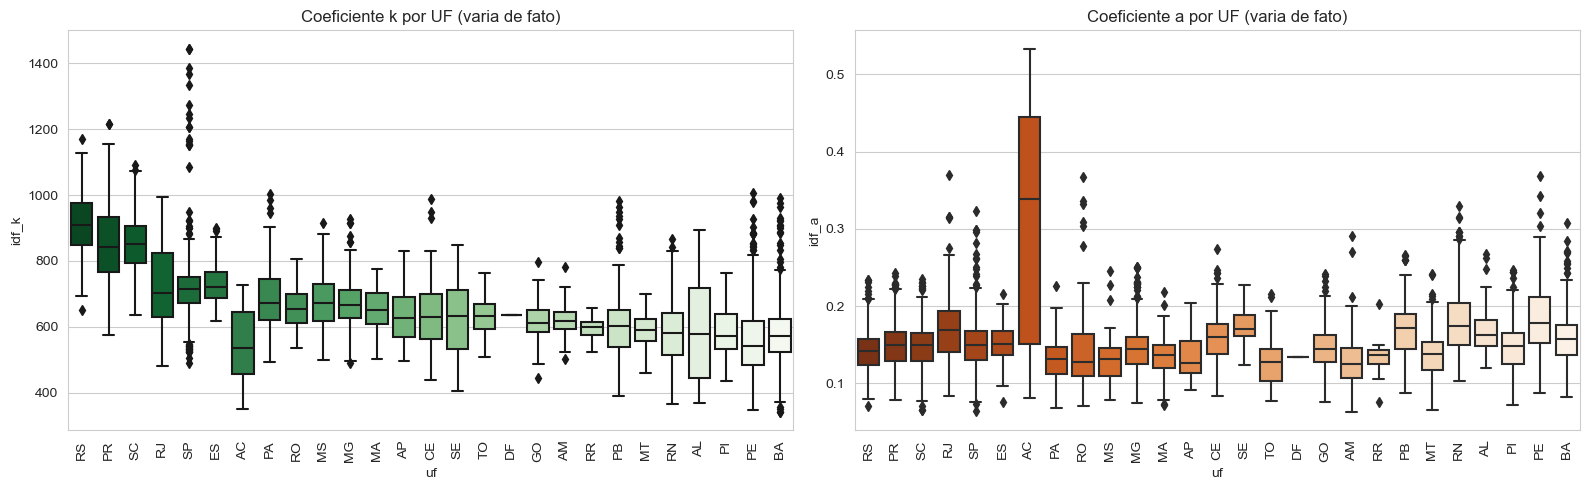

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(data=df, x='uf', y='idf_k', order=ordem_uf, ax=axs[0], palette='Greens_r')
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=90)
axs[0].set_title('Coeficiente k por UF (varia de fato)')

sns.boxplot(data=df, x='uf', y='idf_a', order=ordem_uf, ax=axs[1], palette='Oranges_r')
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=90)
axs[1].set_title('Coeficiente a por UF (varia de fato)')
plt.tight_layout()
plt.show()


## 6. Correlation heatmap between variables

Municipality level: average/std/CV rainfall, IDF coefficients (k, a — the ones that actually vary), fit R², and the estimated 24h/TR=100 years intensity.

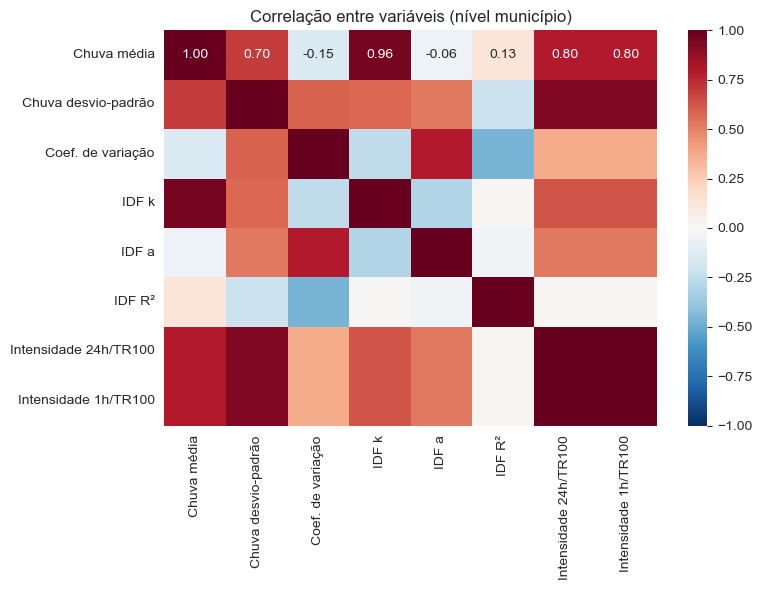

In [10]:
cols_num = ['chuva_media', 'chuva_desvio', 'cv', 'idf_k', 'idf_a', 'idf_r2', 'i_1440min_100anos', 'i_60min_100anos']
nomes_bonitos = {
    'chuva_media': 'Chuva média', 'chuva_desvio': 'Chuva desvio-padrão', 'cv': 'Coef. de variação',
    'idf_k': 'IDF k', 'idf_a': 'IDF a', 'idf_r2': 'IDF R²',
    'i_1440min_100anos': 'Intensidade 24h/TR100', 'i_60min_100anos': 'Intensidade 1h/TR100',
}
corr = df[cols_num].rename(columns=nomes_bonitos).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0)
plt.title('Correlação entre variáveis (nível município)')
plt.tight_layout()
plt.show()


## 7. Heatmap — estimated intensity (TR = 100 years) by state × duration

Shows the regional pattern of projected rainfall intensity for the 100-year return period, across each of the 12 durations of the IDF curve.

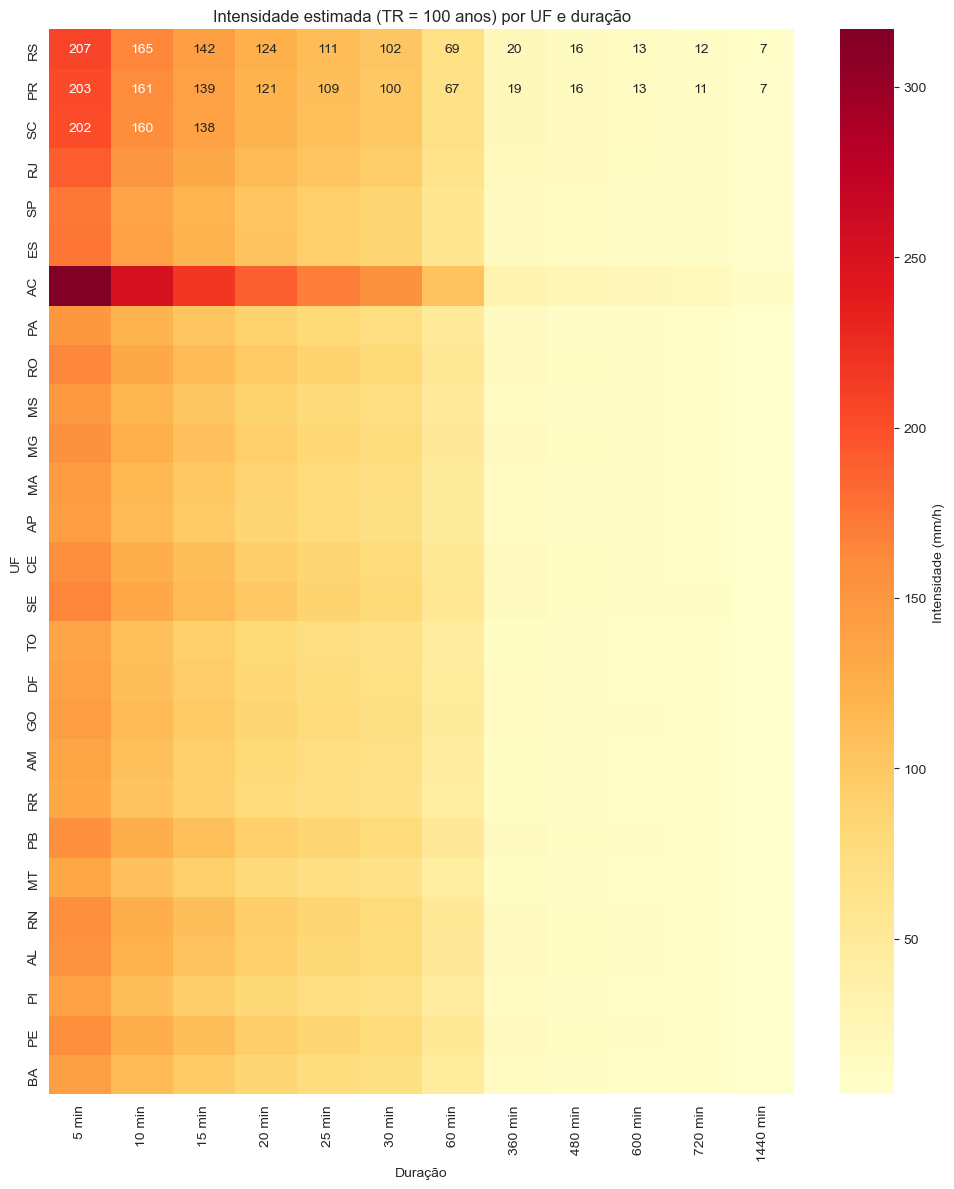

In [11]:
cols_tr100 = [f'i_{d.replace(" ", "")}_100anos' for d in DURACOES]
tabela_uf_duracao = df.groupby('uf')[cols_tr100].mean()
tabela_uf_duracao.columns = DURACOES
tabela_uf_duracao = tabela_uf_duracao.loc[ordem_uf]

plt.figure(figsize=(10, 12))
sns.heatmap(tabela_uf_duracao, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Intensidade (mm/h)'})
plt.title('Intensidade estimada (TR = 100 anos) por UF e duração')
plt.xlabel('Duração')
plt.ylabel('UF')
plt.tight_layout()
plt.show()


## 8. Choropleth maps (geobr)

### 8.1 By state — average annual maximum daily rainfall

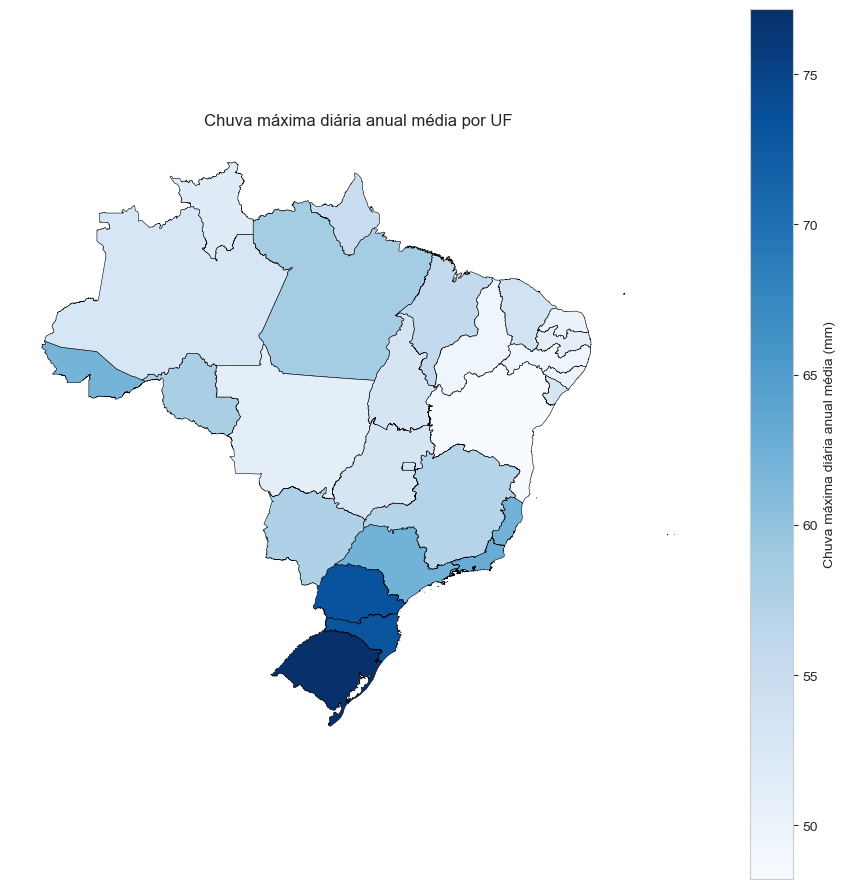

In [12]:
estados_geo = geobr.read_state(year=2020)
estados_geo = estados_geo.merge(tabela_uf.reset_index(), left_on='abbrev_state', right_on='uf', how='left')

fig, ax = plt.subplots(figsize=(9, 9))
estados_geo.plot(column='chuva_media', cmap='Blues', legend=True, edgecolor='black', linewidth=0.4, ax=ax,
                  legend_kwds={'label': 'Chuva máxima diária anual média (mm)'})
ax.set_axis_off()
ax.set_title('Chuva máxima diária anual média por UF')
plt.tight_layout()
plt.show()


### 8.2 Predominant statistical distribution by state

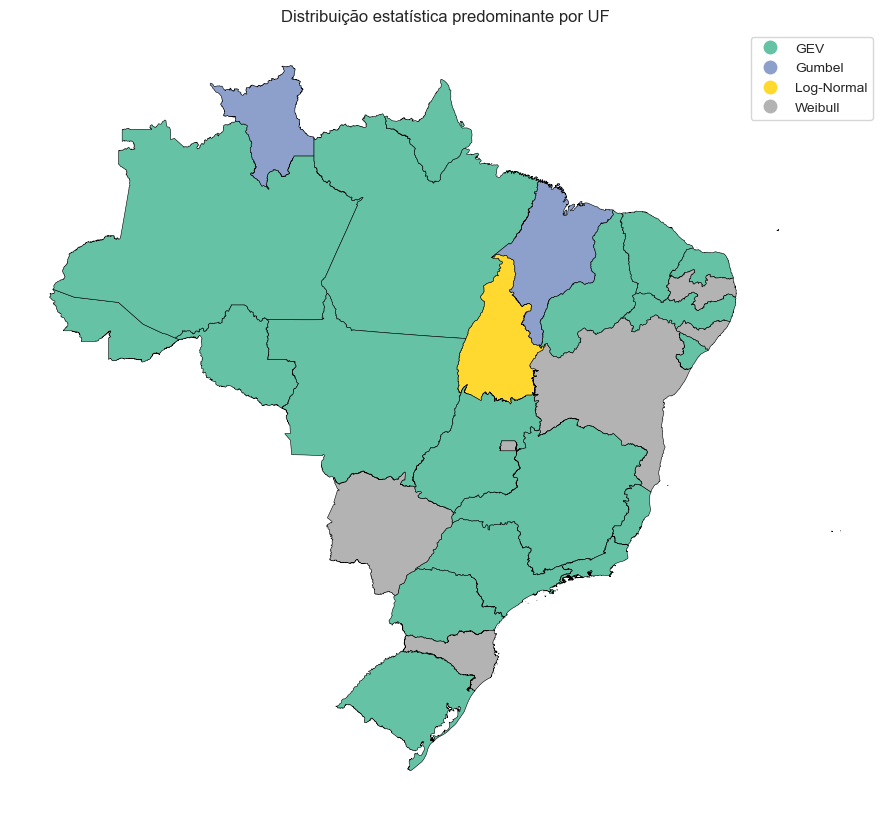

In [13]:
distribuicao_predominante = (
    df.groupby('uf')['distribuicao']
    .agg(lambda s: s.value_counts().idxmax())
    .reset_index(name='distribuicao_predominante')
)
estados_dist = geobr.read_state(year=2020).merge(distribuicao_predominante, left_on='abbrev_state', right_on='uf', how='left')

fig, ax = plt.subplots(figsize=(9, 9))
estados_dist.plot(column='distribuicao_predominante', categorical=True, legend=True, cmap='Set2',
                   edgecolor='black', linewidth=0.4, ax=ax)
ax.set_axis_off()
ax.set_title('Distribuição estatística predominante por UF')
plt.tight_layout()
plt.show()


### 8.3 By municipality — average rainfall and projected intensity (TR = 100 years, 24h)

Downloading the municipal mesh (~5,570 polygons) may take a few seconds on the first run (cached by `geobr` afterward).

2 município(s) presentes na malha geobr mas sem dado (Fernando de Noronha e Vitória — aparecem em cinza no mapa).
1 município(s) com dado mas ausentes da malha geobr 2020 (Boa Esperança do Norte — não aparece no mapa, nem cinza nem colorido).


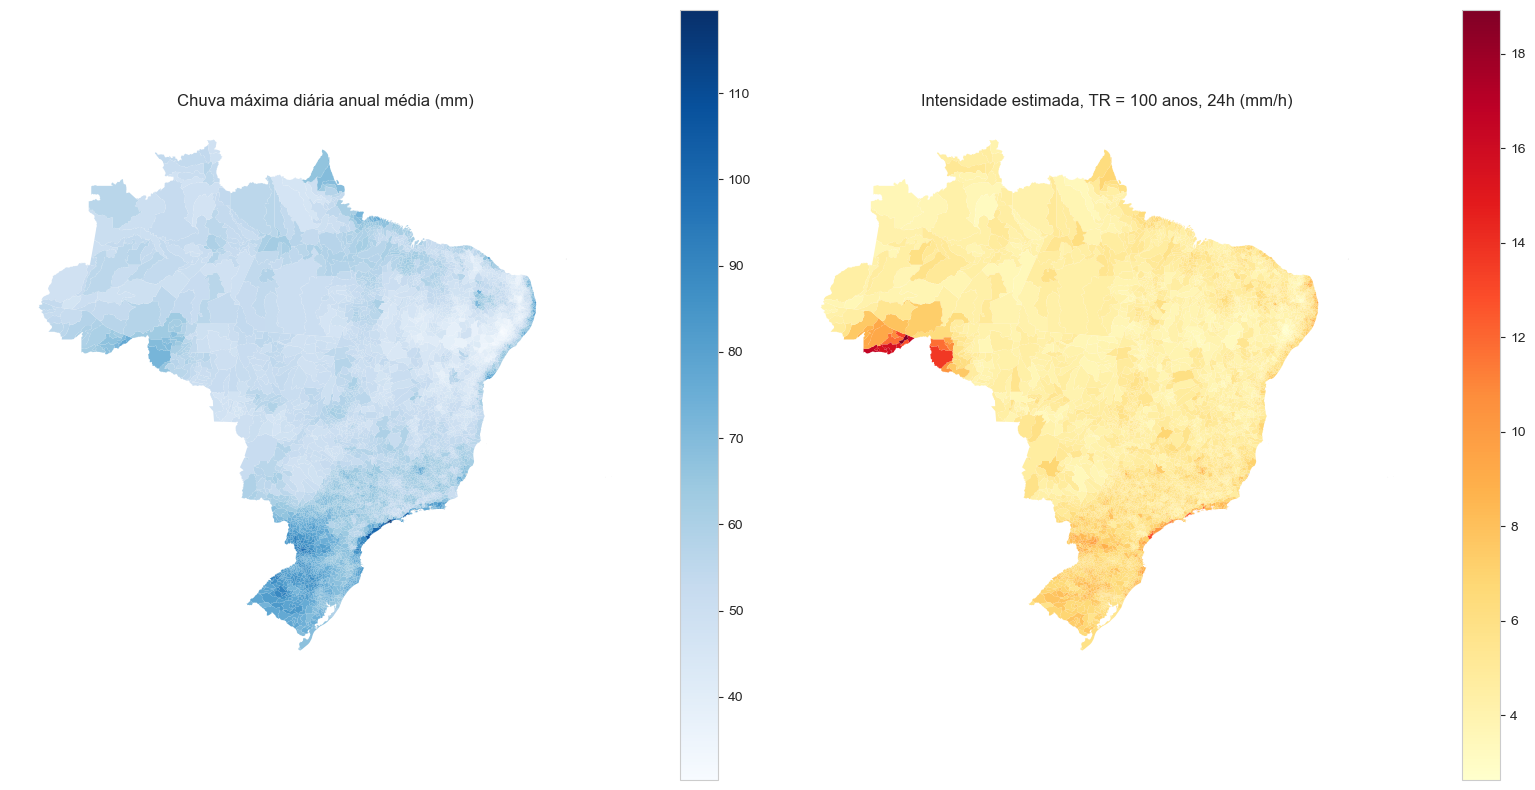

In [14]:
mun_geo = geobr.read_municipality(code_muni='all', year=2020)
mun_geo['codigo_ibge'] = mun_geo['code_muni'].astype('int64').astype(str)
mun_geo = mun_geo.merge(df[['codigo_ibge', 'chuva_media', 'i_1440min_100anos']], on='codigo_ibge', how='left')

sem_dado = mun_geo['chuva_media'].isna().sum()
municipios_sem_poligono = set(df['codigo_ibge']) - set(mun_geo['codigo_ibge'])
print(f'{sem_dado} município(s) presentes na malha geobr mas sem dado (Fernando de Noronha e Vitória — aparecem em cinza no mapa).')
print(f'{len(municipios_sem_poligono)} município(s) com dado mas ausentes da malha geobr 2020 '
      f'(Boa Esperança do Norte — não aparece no mapa, nem cinza nem colorido).')

fig, axs = plt.subplots(1, 2, figsize=(16, 8))
mun_geo.plot(column='chuva_media', cmap='Blues', legend=True, ax=axs[0], linewidth=0,
             missing_kwds={'color': 'lightgrey', 'label': 'sem dado'})
axs[0].set_axis_off()
axs[0].set_title('Chuva máxima diária anual média (mm)')

mun_geo.plot(column='i_1440min_100anos', cmap='YlOrRd', legend=True, ax=axs[1], linewidth=0,
             missing_kwds={'color': 'lightgrey', 'label': 'sem dado'})
axs[1].set_axis_off()
axs[1].set_title('Intensidade estimada, TR = 100 anos, 24h (mm/h)')
plt.tight_layout()
plt.show()


## 9. Numerical summary for the paper

In [15]:
print('=== Resumo para o artigo ===')
print(f'Total de municípios com curva IDF: {len(df)} de {len(df) + len(df_ignorados)} municípios brasileiros')
print(f'Período de análise: {df_long["ano"].min()}–{df_long["ano"].max()} ({df_long["ano"].nunique()} anos)')
print(f'Chuva máxima diária anual média nacional: {df["chuva_media"].mean():.1f} mm (desvio-padrão entre municípios: {df["chuva_media"].std():.1f} mm)')

uf_maior, uf_menor = tabela_uf.index[0], tabela_uf.index[-1]
print(f'UF com maior chuva máxima média: {uf_maior} ({tabela_uf.loc[uf_maior, "chuva_media"]:.1f} mm)')
print(f'UF com menor chuva máxima média: {uf_menor} ({tabela_uf.loc[uf_menor, "chuva_media"]:.1f} mm)')

dist_top = df['distribuicao'].value_counts()
print(f'Distribuição mais frequente nacionalmente: {dist_top.index[0]} '
      f'({dist_top.iloc[0]} municípios, {100 * dist_top.iloc[0] / len(df):.1f}%)')

print(f'R² da calibração IDF: média {df["idf_r2"].mean():.4f} (mín. {df["idf_r2"].min():.4f}, máx. {df["idf_r2"].max():.4f})')
print(f'Coeficiente b da equação IDF: {df["idf_b"].mean():.2f} ± {df["idf_b"].std():.5f} min '
      f'(praticamente constante nacionalmente — ver limitação metodológica)')
print(f'Coeficiente c da equação IDF: {df["idf_c"].mean():.4f} ± {df["idf_c"].std():.6f} '
      f'(praticamente constante nacionalmente — ver limitação metodológica)')


=== Resumo para o artigo ===
Total de municípios com curva IDF: 5569 de 5571 municípios brasileiros
Período de análise: 1961–2025 (65 anos)
Chuva máxima diária anual média nacional: 59.2 mm (desvio-padrão entre municípios: 11.6 mm)
UF com maior chuva máxima média: RS (77.2 mm)
UF com menor chuva máxima média: BA (48.2 mm)
Distribuição mais frequente nacionalmente: GEV (1489 municípios, 26.7%)
R² da calibração IDF: média 0.9990 (mín. 0.9978, máx. 0.9996)
Coeficiente b da equação IDF: 11.83 ± 0.00000 min (praticamente constante nacionalmente — ver limitação metodológica)
Coeficiente c da equação IDF: 0.7580 ± 0.000000 (praticamente constante nacionalmente — ver limitação metodológica)


## 10. Methodological limitations to cite in the paper

(Full detail in `MEMORIA_PROJETO.md`.)

1. **Sampling at the centroid, not the municipal polygon**: each value represents the 0.1° (~11 km) pixel of the Xavier BR-DWGD grid that contains the municipality's centroid, not the spatial maximum within the municipal territory.
2. **KS test with parameters estimated from the sample itself** tends to accept distributions "too easily" (a known issue — the Lilliefors correction was not applied).
3. **Distributions with no extreme-value-theory justification** (Normal, Gamma, Weibull) were tested alongside Gumbel/GEV — they can win the fit to the "body" of the distribution without necessarily describing the tail well.
4. **DAEE/CETESB (1980) disaggregation factors are regional (SP)**, applied here to every municipality in Brazil — direct consequence: the `b` and `c` coefficients of the IDF equation come out practically constant nationwide (section 5), reflecting the fixed shape of the disaggregation, not a real difference in sub-daily rainfall regime between regions.
5. **R²/MAE/RMSE of the IDF calibration are optimistic**: the 60 points (12 durations × 5 return periods) used in the calibration are not independent observations — they are quantiles extrapolated from a smooth curve derived from only 65 annual values per municipality.
6. **Two municipalities without a valid series** (Fernando de Noronha — outside the grid coverage; Vitória/ES — asset centroid with an incorrect coordinate, falling in the ocean) were excluded from the whole analysis.
7. **Boa Esperança do Norte (MT)** is absent from the 2020 `geobr` geographic mesh used in the municipal maps (a consequence of the mesh being from 2020 and the municipality possibly being more recent) — present in every other statistic.
